In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [33]:
df = pd.read_csv("msd03_ablation.csv", index_col=0)

In [34]:
df

,obj_id,vol_avg_dice,global_allres_sim,global_lowres_sim,global_masked_allres_sim,global_masked_lowres_sim,local_allres_sim,local_lowres_sim,local_masked_allres_sim,local_masked_lowres_sim
0,liver_92.nii.gz_1,tensor(0.6245),"[172, 0]","[172, 0]","[161, 11]","[151, 21]","[172, 0]","[172, 0]","[168, 4]","[171, 1]"
1,liver_92.nii.gz_2,tensor(0.),"[36, 2]","[37, 1]","[3, 35]","[14, 24]","[38, 0]","[38, 0]","[31, 7]","[35, 3]"
2,liver_60.nii.gz_1,tensor(0.6732),"[71, 1]","[61, 11]","[62, 10]","[51, 21]","[72, 0]","[72, 0]","[65, 7]","[67, 5]"
3,liver_60.nii.gz_2,tensor(0.),"[11, 0]","[11, 0]","[6, 5]","[5, 6]","[11, 0]","[11, 0]","[7, 4]","[7, 4]"
4,liver_34.nii.gz_1,tensor(0.3684),"[91, 0]","[85, 6]","[86, 5]","[79, 12]","[91, 0]","[91, 0]","[91, 0]","[88, 3]"
5,liver_70.nii.gz_1,tensor(0.7291),"[103, 0]","[102, 1]","[92, 11]","[89, 14]","[103, 0]","[103, 0]","[97, 6]","[101, 2]"
6,liver_70.nii.gz_2,tensor(0.),"[44, 0]","[43, 1]","[31, 13]","[33, 11]","[44, 0]","[44, 0]","[30, 14]","[33, 11]"
7,liver_125.nii.gz_1,tensor(0.6704),"[105, 0]","[92, 13]","[85, 20]","[82, 23]","[105, 0]","[105, 0]","[97, 8]","[103, 2]"
8,liver_125.nii.gz_2,tensor(0.),"[2, 0]","[2, 0]","[1, 1]","[1, 1]","[2, 0]","[2, 0]","[2, 0]","[2, 0]"
9,liver_88.nii.gz_1,tensor(0.6034),"[168, 0]","[167, 1]","[156, 12]","[145, 23]","[168, 0]","[168, 0]","[166, 2]","[161, 7]"


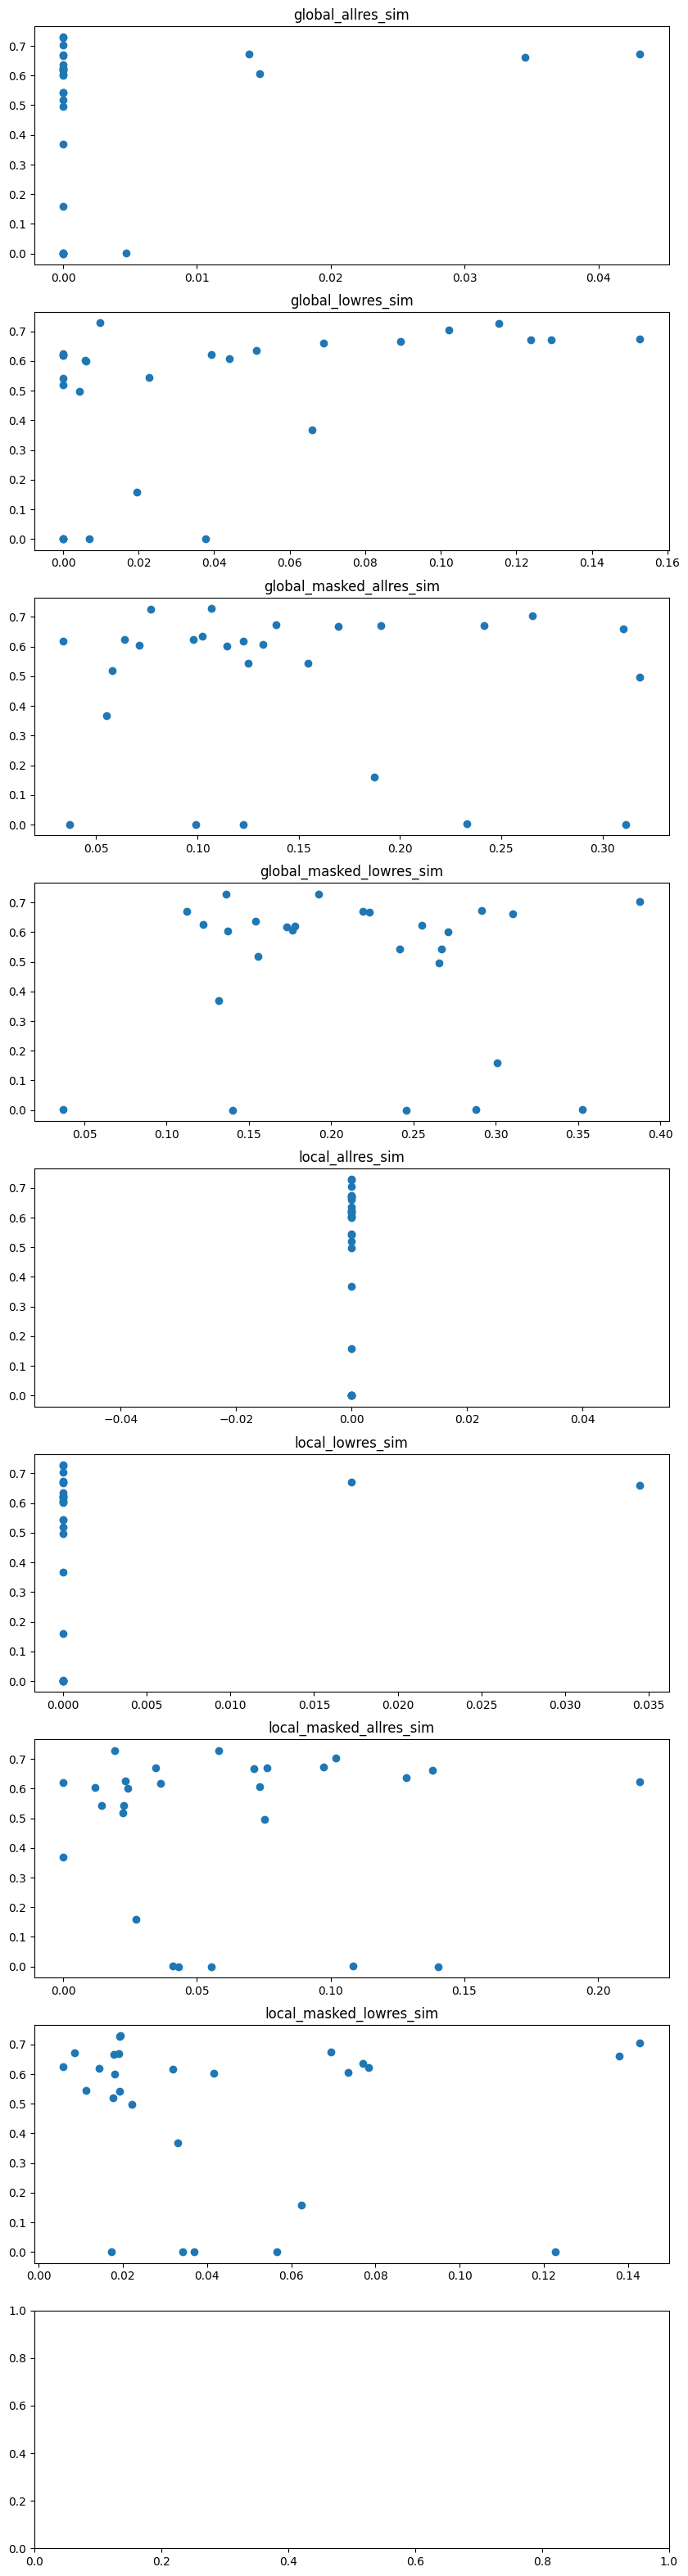

In [37]:
fig, axes = plt.subplots(nrows=len(df.columns) - 1, figsize=(10,40))
metrics = df.columns[~df.columns.isin(["vol_avg_dice", "obj_id"])]
for idx, metric in enumerate(metrics):
    point = []
    for i in range(len(df)):
        obj_id = int(df.loc[i, "obj_id"][-1])
        if obj_id == 2:
            continue
        
        dice = eval("torch." + df.loc[i, "vol_avg_dice"]).item()
        num = eval(df.loc[i, metric])
        rate = num[1] / (num[0] + num[1] + 1e-8)
        point.append((dice, rate))
    
    dice_y, rate_x = zip(*point)
    
    axes[idx].set_title(metric)
    axes[idx].scatter(x=rate_x, y=dice_y)